In [2]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torch import optim
import time
from sklearn.model_selection import train_test_split

In [8]:
data = pd.read_csv("flatten_data.csv")
data.head()

,frame,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,create,direct,disruption,finish,quick_break,set_play,transition,direction,lead_to_goal,match_id
0,28.0,0.11,0.32,0.29,0.49,0.31,0.44,0.41,0.50,0.49,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1886347
1,48.0,0.12,0.30,0.29,0.54,0.30,0.46,0.40,0.55,0.54,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1886347
2,49.0,0.12,0.29,0.29,0.54,0.30,0.46,0.40,0.56,0.55,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1886347
3,50.0,0.12,0.29,0.29,0.55,0.30,0.46,0.40,0.56,0.55,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1886347
4,51.0,0.12,0.29,0.29,0.55,0.30,0.46,0.40,0.56,0.56,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1886347


In [9]:
data.describe()

,frame,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,create,direct,disruption,finish,quick_break,set_play,transition,direction,lead_to_goal,match_id
count,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,...,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,2.072680e+05
mean,30552.832208,0.134013,0.344393,0.351709,0.413596,0.428667,0.445072,0.459798,0.527198,0.558067,...,0.380802,0.040233,0.006103,0.254154,0.018102,0.022150,0.038197,0.473947,0.008578,1.970869e+06
std,19281.857122,0.076630,0.159004,0.162062,0.191870,0.195291,0.186587,0.180825,0.191495,0.187880,...,0.485585,0.196506,0.077884,0.435386,0.133321,0.147172,0.191672,0.499322,0.092221,4.912615e+04
min,12.000000,-0.040000,-0.020000,-0.020000,-0.020000,-0.030000,0.010000,0.020000,0.010000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.886347e+06
25%,13178.000000,0.070000,0.220000,0.230000,0.270000,0.280000,0.300000,0.330000,0.390000,0.430000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.925299e+06
50%,27695.000000,0.130000,0.350000,0.350000,0.400000,0.420000,0.440000,0.460000,0.530000,0.560000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.996435e+06
75%,47576.250000,0.190000,0.460000,0.460000,0.540000,0.560000,0.580000,0.590000,0.670000,0.700000,...,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.013725e+06
max,71271.000000,0.950000,1.000000,0.990000,1.030000,1.030000,1.010000,1.020000,1.030000,1.020000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.017461e+06


In [10]:
print(data["lead_to_goal"].value_counts())

lead_to_goal
0.0    205490
1.0      1778
Name: count, dtype: int64


Should have 207268 rows

In [11]:
data.isna().value_counts()

frame  x1     x2     x3     x4     x5     x6     x7     x8     x9     x10    x11    x12    x13    x14    x15    x16    x17    x18    x19    x20    x21    x22    y1     y2     y3     y4     y5     y6     y7     y8     y9     y10    y11    y12    y13    y14    y15    y16    y17    y18    y19    y20    y21    y22    vx1    vx2    vx3    vx4    vx5    vx6    vx7    vx8    vx9    vx10   vx11   vx12   vx13   vx14   vx15   vx16   vx17   vx18   vx19   vx20   vx21   vx22   vy1    vy2    vy3    vy4    vy5    vy6    vy7    vy8    vy9    vy10   vy11   vy12   vy13   vy14   vy15   vy16   vy17   vy18   vy19   vy20   vy21   vy22   speed1  speed2  speed3  speed4  speed5  speed6  speed7  speed8  speed9  speed10  speed11  speed12  speed13  speed14  speed15  speed16  speed17  speed18  speed19  speed20  speed21  speed22  ax1    ax2    ax3    ax4    ax5    ax6    ax7    ax8    ax9    ax10   ax11   ax12   ax13   ax14   ax15   ax16   ax17   ax18   ax19   ax20   ax21   ax22   ay1    ay2    ay3    ay4    ay5   

In [12]:
X = data.drop(columns=["lead_to_goal", "frame", "match_id"])
y = data["lead_to_goal"]
X_train_strat, X_temp_strat, y_train_strat, y_temp_strat = train_test_split(X, y, train_size = 0.6,
                                                                            random_state=42, 
                                                                            shuffle=True,
                                                                            stratify=y)

X_val_strat, X_test_strat, y_val_strat, y_test_strat = train_test_split(X_temp_strat, y_temp_strat, train_size = 0.5,
                                                                            random_state=42, 
                                                                            shuffle=True,
                                                                            stratify=y_temp_strat)

In [13]:
print(y_train_strat.value_counts())

lead_to_goal
0.0    123293
1.0      1067
Name: count, dtype: int64


In [21]:
class EPV(nn.Module):
    def __init__(self):
        super(EPV, self).__init__()
        self.layer1 = nn.Linear(167, 250)
        self.layer2 = nn.Linear(250, 150)
        self.layer3 = nn.Linear(150, 50)
        self.layer4 = nn.Linear(50, 1)
        self.act = nn.LeakyReLU(0.1)
        self.drop = nn.Dropout(0.2)
        self.out = nn.Sigmoid()

        
       

    def forward(self, x):
        x_out = self.drop(self.act(self.layer1(x)))
        x_out = self.drop(self.act(self.layer2(x_out)))
        x_out = self.drop(self.act(self.layer3(x_out)))
        out = self.out(self.layer4(x_out))
        return out

In [ ]:
# init params
epochs = 50
lr = 0.0001
n = X_train_strat.shape[0]
input_size = X_train_strat.shape[1]
batch_size = 128
# helping class imbalance ~ about 0.008
weight = torch.tensor([123293 / 1067]) # from 2 cells above
loss = nn.BCEWithLogitsLoss(pos_weight=weight)
epv_model = EPV()
optimizer = optim.Adam(epv_model.parameters(), lr=lr)
num_batches = len(X_train_strat) // batch_size

In [35]:
errors = []
vals = []
start = time.time()

# set device
device = "cuda" if torch.cuda.is_available() else "cpu"
epv_model.to(device)
print(device)

for i in range(epochs): # epoch level
    epv_model.train()
    print(f"training epoch {i+1}")
    epoch_start = time.time() # track time for epoch
    epoch_error = 0
    for j in range(num_batches): # batch level
        batch_train = X_train_strat[j*batch_size:(j+1)*batch_size].values # get values
        batch_label = y_train_strat[j*batch_size:(j+1)*batch_size].values
        error = 0
        for x, y in zip(batch_train, batch_label):
            x = torch.FloatTensor(x).to(device) # convert to tensor and device
            y = torch.FloatTensor([y]).to(device)
            error += loss(epv_model(x), y) # sum loss
        epv_model.zero_grad()
        error.backward()
        optimizer.step()
        epoch_error += (error.item() / n)
    errors.append(epoch_error) # append value to list
    print(f"Average error for epoch {i+1} is {epoch_error:.4f}")
    
    epoch_end = time.time() # get time
    diff = epoch_end - epoch_start
    print(f"Epoch time: {diff:.2f} seconds")
    
    epv_model.eval()
    y_preds = epv_model(torch.FloatTensor(X_test_strat.values).to(device))
    y_val_tensor = torch.FloatTensor(y_test_strat.values).to(device)
    val_loss = loss(y_preds, y_val_tensor.unsqueeze(dim=1)).item()
    print(f"Val loss for epoch {i+1} is {val_loss:.4f}")
    vals.append(val_loss)
    


end = time.time() # get overall time
overall = end - start
print(f"Execution time: {overall/60:.2f} minutes")

cpu
training epoch 1
Average error for epoch 1 is 1.3769
Epoch time: 28.53 seconds
Val loss for epoch 1 is 1.3560
training epoch 2
Average error for epoch 2 is 1.3445
Epoch time: 28.42 seconds
Val loss for epoch 2 is 1.3227
training epoch 3
Average error for epoch 3 is 1.3002
Epoch time: 29.10 seconds
Val loss for epoch 3 is 1.2540
training epoch 4
Average error for epoch 4 is 1.2479
Epoch time: 29.41 seconds
Val loss for epoch 4 is 1.2068
training epoch 5
Average error for epoch 5 is 1.2231
Epoch time: 27.97 seconds
Val loss for epoch 5 is 1.1875
training epoch 6
Average error for epoch 6 is 1.2104
Epoch time: 28.56 seconds
Val loss for epoch 6 is 1.1804
training epoch 7
Average error for epoch 7 is 1.1990
Epoch time: 27.95 seconds
Val loss for epoch 7 is 1.1712
training epoch 8
Average error for epoch 8 is 1.1920
Epoch time: 28.87 seconds
Val loss for epoch 8 is 1.1553
training epoch 9
Average error for epoch 9 is 1.1847
Epoch time: 28.78 seconds
Val loss for epoch 9 is 1.1559
traini

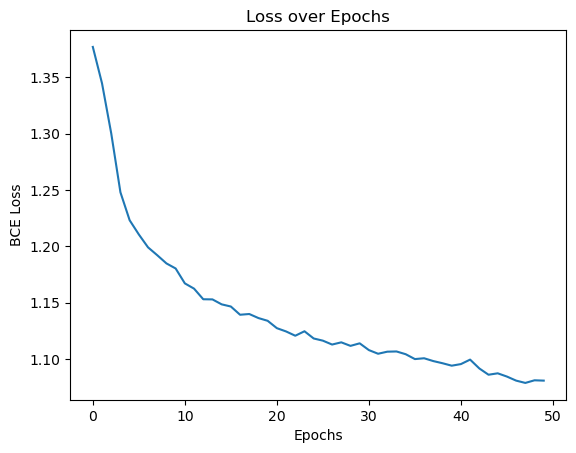

In [36]:
# plot loss
plt.plot(errors)
plt.xlabel("Epochs")
plt.ylabel("BCE Loss")
plt.title("Loss over Epochs")
#plt.savefig("train_loss.png")
plt.show()

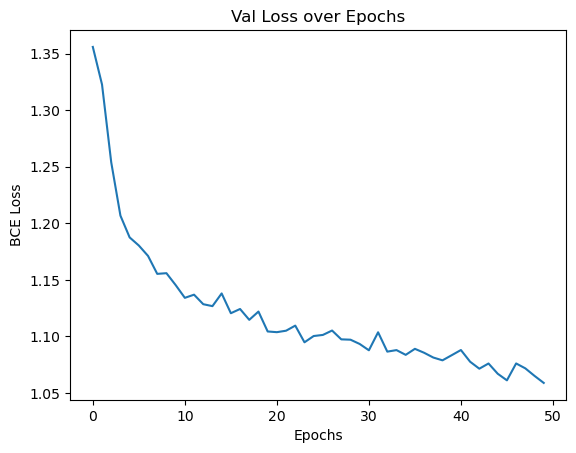

In [37]:
# plot loss
plt.plot(vals)
plt.xlabel("Epochs")
plt.ylabel("BCE Loss")
plt.title("Val Loss over Epochs")
#plt.savefig("val_loss.png")
plt.show()

In [38]:
epv_model.eval()
y_preds = epv_model(torch.FloatTensor(X_test_strat.values).to(device)).detach().numpy()

In [39]:
print(y_preds)

[[1.0901490e-09]
 [8.2624705e-05]
 [1.4315387e-14]
 ...
 [3.4492553e-13]
 [2.9301454e-08]
 [9.9784100e-01]]


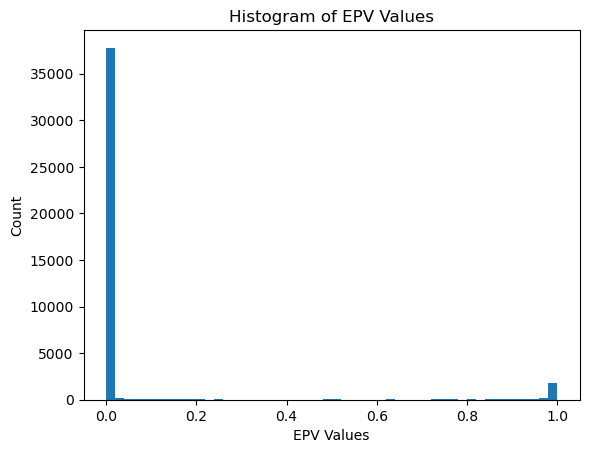

In [40]:
plt.hist(y_preds, bins=50, range=(0,1))
plt.xlabel("EPV Values")
plt.ylabel("Count")
plt.title("Histogram of EPV Values")
plt.show()

In [41]:
print(min(y_preds))
print(max(y_preds))
np.mean(y_preds)

[0.]
[1.]


np.float32(0.06304909)

In [42]:
torch.save(epv_model, "epv_model_weighted.pth")

In [ ]:
PITCH_WIDTH = 68
PITCH_LENGTH = 105

width_min = -PITCH_WIDTH/2
width_max = PITCH_WIDTH/2
length_min = -PITCH_LENGTH/2
length_max = PITCH_LENGTH/2